In [60]:
# Autoreload para refletir mudanças no config sem reiniciar kernel
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [74]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats as scipy_stats
import mlflow

In [62]:
from churn_telecom.config import get_logger
logger = get_logger("0.02_eda_univariate")

In [63]:
# Célula 3 — módulo interno do projeto
from churn_telecom.config import (
    COLS_CAT,
    COLS_NUM,
    COLS_POS,
    DATA_INTERIM,
    LABEL_COL,
    RANDOM_STATE,
    REPORTS_FIGURES,
    TARGET,
    CORES,
    MLFLOW_EXPERIMENT,
    MLFLOW_TRACKING_URI,
    setup_mlflow,
)

In [64]:
# Célula 5 — carrega dados
df = pd.read_parquet(DATA_INTERIM / "telco_typed.parquet")
logger.info("Dataset carregado. Shape: %s", df.shape)
df.head()

Dataset carregado. Shape: (7043, 20)


,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1


In [65]:
# Célula 6 — garante que o diretório de saída existe
REPORTS_FIGURES.mkdir(parents=True, exist_ok=True)

MLflow run iniciada | run_id=17c22b20ece34eb2b3ba568429509680 | experiment=churn-telecom


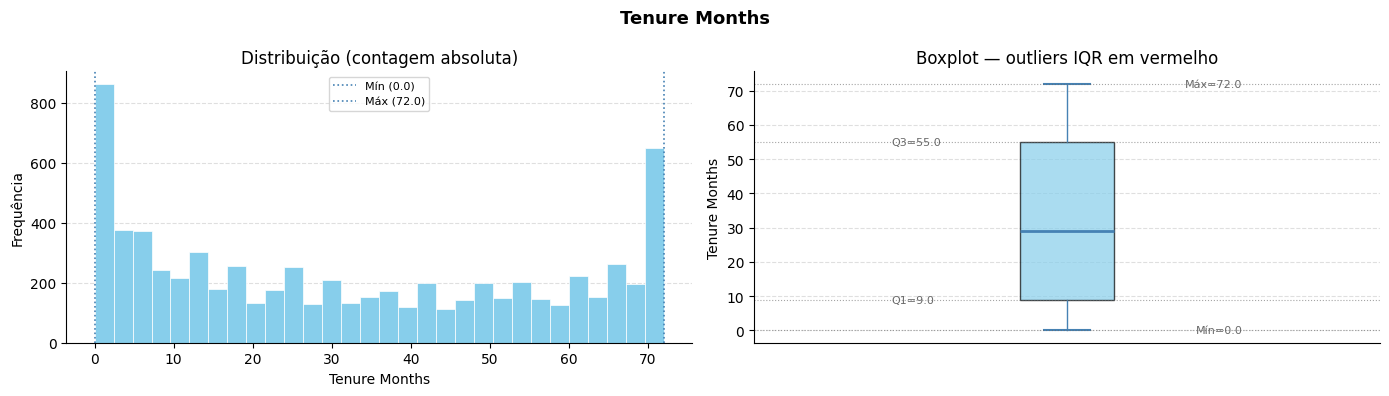

Tenure Months | n=7043 | média=32.37 | mediana=29.00 | std=24.56 | min=0.00 | max=72.00 | q1=9.00 | q3=55.00 | iqr=46.00 | lim_inf=-60.00 | lim_sup=124.00 | outliers_iqr=0 (0.00%) | outliers_zscore=0 (0.00%)
Artefato registrado no MLflow: eda/numericas/univariate_num_tenure_months.png


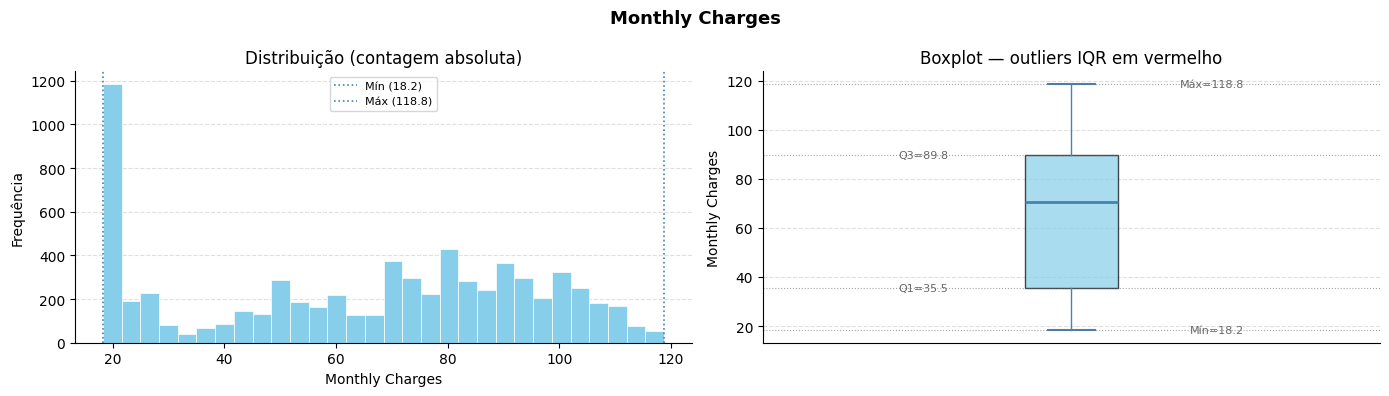

Monthly Charges | n=7043 | média=64.76 | mediana=70.35 | std=30.09 | min=18.25 | max=118.75 | q1=35.50 | q3=89.85 | iqr=54.35 | lim_inf=-46.02 | lim_sup=171.38 | outliers_iqr=0 (0.00%) | outliers_zscore=0 (0.00%)
Artefato registrado no MLflow: eda/numericas/univariate_num_monthly_charges.png


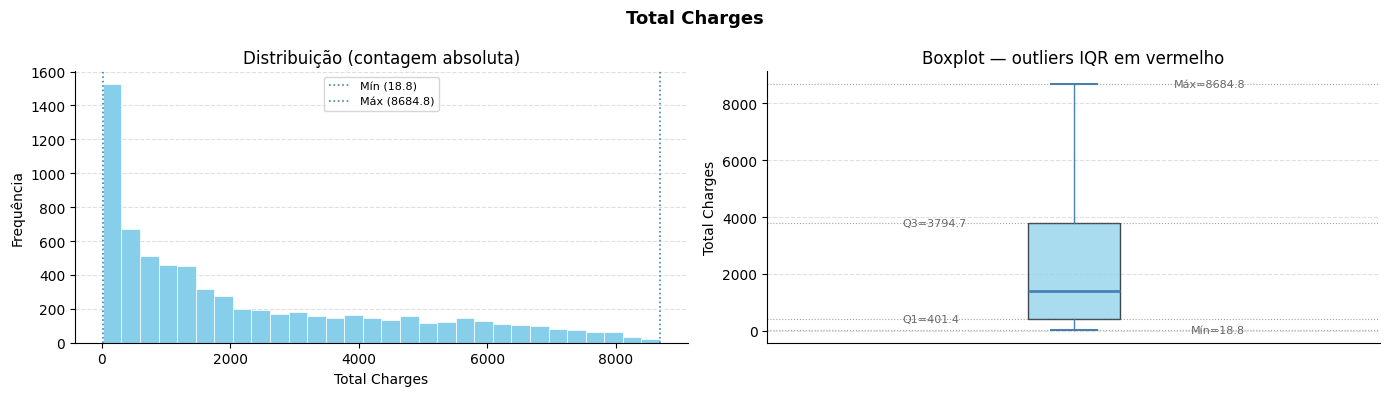

Total Charges | n=7032 | média=2283.30 | mediana=1397.47 | std=2266.77 | min=18.80 | max=8684.80 | q1=401.45 | q3=3794.74 | iqr=3393.29 | lim_inf=-4688.48 | lim_sup=8884.67 | outliers_iqr=0 (0.00%) | outliers_zscore=0 (0.00%)
Artefato registrado no MLflow: eda/numericas/univariate_num_total_charges.png
MLflow run finalizada | run_id=17c22b20ece34eb2b3ba568429509680


In [76]:
# ── EDA Univariada — Variáveis Numéricas ──────────────────────────────────────
with mlflow.start_run(run_name="0.02_eda_univariate_numericas") as run:
    # primeira linha da run — vincula o log ao MLflow
    logger.info("MLflow run iniciada | run_id=%s | experiment=%s",
                run.info.run_id, MLFLOW_EXPERIMENT)

    # ── Tags da run ───────────────────────────────────────────────────────────
    mlflow.set_tags({
        "notebook": "0.02_eda_univariate",
        "fase":     "eda",
        "tipo":     "numericas",
        "autor":    "vab",
        "dataset":  "telco_typed.parquet",
    })

    # ── Parâmetros globais da run ─────────────────────────────────────────────
    mlflow.log_params({
        "n_amostras":     len(df),
        "n_features_num": len(COLS_NUM),
        "random_state":   RANDOM_STATE,
    })

    for col in COLS_NUM:
        series = df[col].dropna()

        # ── Estatísticas descritivas ──────────────────────────────────────────
        q1      = series.quantile(0.25)
        q3      = series.quantile(0.75)
        iqr     = q3 - q1
        lim_inf = q1 - 1.5 * iqr
        lim_sup = q3 + 1.5 * iqr
        val_min = series.min()
        val_max = series.max()

        # Outliers via IQR
        mask_iqr    = (series < lim_inf) | (series > lim_sup)
        n_out_iqr   = mask_iqr.sum()
        pct_out_iqr = n_out_iqr / len(series) * 100

        # Outliers via Z-score (|z| > 3)
        z_scores  = np.abs(scipy_stats.zscore(series))
        mask_z    = z_scores > 3
        n_out_z   = mask_z.sum()
        pct_out_z = n_out_z / len(series) * 100

        # ── Plot ──────────────────────────────────────────────────────────────
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        fig.suptitle(col, fontsize=13, fontweight="bold")

        # Histograma — contagem absoluta, apenas mín e máx
        axes[0].hist(
            series,
            bins=30,
            color=CORES["primaria"],
            edgecolor="white",
            linewidth=0.5,
            zorder=2,
        )
        axes[0].axvline(val_min, color=CORES["secundaria"], linestyle=":", linewidth=1.2,
                        label=f"Mín ({val_min:.1f})")
        axes[0].axvline(val_max, color=CORES["secundaria"], linestyle=":", linewidth=1.2,
                        label=f"Máx ({val_max:.1f})")
        axes[0].set_title("Distribuição (contagem absoluta)")
        axes[0].set_xlabel(col)
        axes[0].set_ylabel("Frequência")
        axes[0].yaxis.grid(True, linestyle="--", alpha=0.4, zorder=0)
        axes[0].set_axisbelow(True)
        axes[0].spines[["top", "right"]].set_visible(False)
        axes[0].legend(fontsize=8)

        # Boxplot univariado — Q1, Q3, mín, máx anotados
        axes[1].boxplot(
            series,
            vert=True,
            patch_artist=True,
            boxprops=dict(facecolor=CORES["primaria"], alpha=0.7),
            medianprops=dict(color=CORES["secundaria"], linewidth=2),
            whiskerprops=dict(color=CORES["secundaria"], linewidth=1),
            capprops=dict(color=CORES["secundaria"], linewidth=1.5),
            flierprops=dict(marker="o", color=CORES["alerta"], alpha=0.5, markersize=4),
        )
        for val, label, side in [
            (q1,      f"Q1={q1:.1f}",       "left"),
            (q3,      f"Q3={q3:.1f}",       "left"),
            (val_min, f"Mín={val_min:.1f}", "right"),
            (val_max, f"Máx={val_max:.1f}", "right"),
        ]:
            axes[1].axhline(val, color=CORES["neutro"], linestyle=":", linewidth=0.8, alpha=0.6)
            x_pos = 0.72 if side == "left" else 1.28
            axes[1].text(
                x_pos, val, label,
                va="center", fontsize=8,
                color=CORES["neutro"],
                ha="left" if side == "left" else "right",
            )
        axes[1].set_title("Boxplot — outliers IQR em vermelho")
        axes[1].set_ylabel(col)
        axes[1].set_xticks([])
        axes[1].yaxis.grid(True, linestyle="--", alpha=0.4, zorder=0)
        axes[1].set_axisbelow(True)
        axes[1].spines[["top", "right"]].set_visible(False)

        plt.tight_layout()
        output_path = REPORTS_FIGURES / f"univariate_num_{col.lower().replace(' ', '_')}.png"
        plt.savefig(output_path, dpi=120, bbox_inches="tight")
        plt.show()
        plt.close()

        # ── Métricas no MLflow — uma entrada por coluna ───────────────────────
        col_key = col.lower().replace(" ", "_")
        mlflow.log_metrics({
            f"{col_key}_mean":            round(float(series.mean()),   2),
            f"{col_key}_median":          round(float(series.median()), 2),
            f"{col_key}_std":             round(float(series.std()),    2),
            f"{col_key}_min":             round(float(val_min),         2),
            f"{col_key}_max":             round(float(val_max),         2),
            f"{col_key}_q1":              round(float(q1),              2),
            f"{col_key}_q3":              round(float(q3),              2),
            f"{col_key}_iqr":             round(float(iqr),             2),
            f"{col_key}_lim_inf":         round(float(lim_inf),         2),
            f"{col_key}_lim_sup":         round(float(lim_sup),         2),
            f"{col_key}_outliers_iqr_n":  int(n_out_iqr),
            f"{col_key}_outliers_iqr_pct":round(pct_out_iqr,            2),
            f"{col_key}_outliers_z_n":    int(n_out_z),
            f"{col_key}_outliers_z_pct":  round(pct_out_z,              2),
        })

        # ── Artefato no MLflow — subpasta por tipo ────────────────────────────
        mlflow.log_artifact(str(output_path), artifact_path="eda/numericas")

        # ── Log estruturado ───────────────────────────────────────────────────
        logger.info(
            "%s | n=%d | média=%.2f | mediana=%.2f | std=%.2f | "
            "min=%.2f | max=%.2f | "
            "q1=%.2f | q3=%.2f | iqr=%.2f | "
            "lim_inf=%.2f | lim_sup=%.2f | "
            "outliers_iqr=%d (%.2f%%) | "
            "outliers_zscore=%d (%.2f%%)",
            col, len(series),
            series.mean(), series.median(), series.std(),
            val_min, val_max,
            q1, q3, iqr,
            lim_inf, lim_sup,
            n_out_iqr, pct_out_iqr,
            n_out_z,   pct_out_z,
        )
        logger.info("Artefato registrado no MLflow: eda/numericas/%s", output_path.name)

    logger.info("MLflow run finalizada | run_id=%s", run.info.run_id)

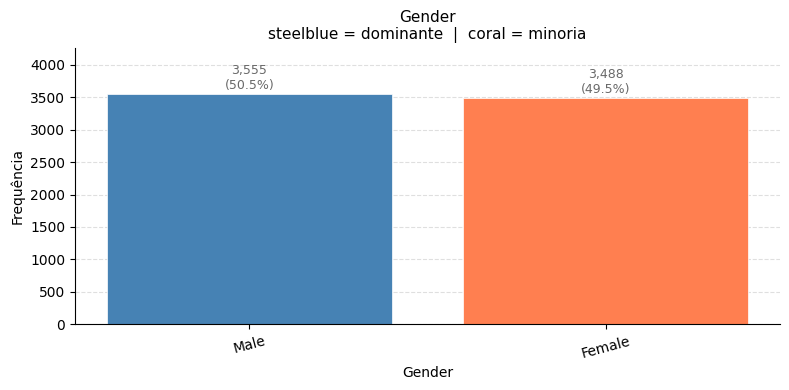

Gender | n=7043 | nulos=0 | categorias=2 | dominante='Male' (50.5%) | minoria='Female' (49.5%) | cats_raras=0 (<1%) | alta_concentracao=False
Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\projeto\reports\figures\univariate_cat_gender.png


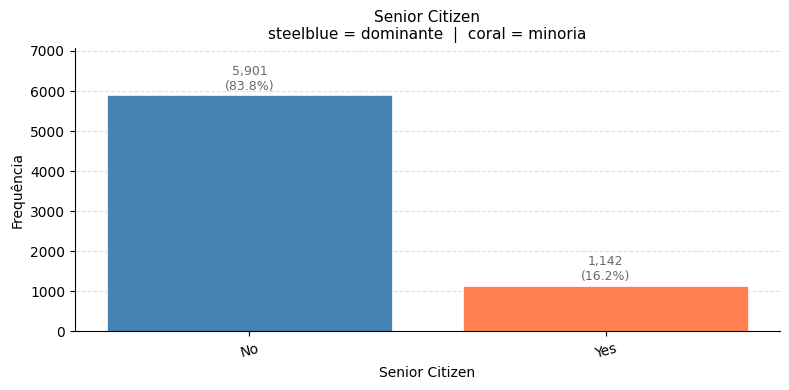

Senior Citizen | n=7043 | nulos=0 | categorias=2 | dominante='No' (83.8%) | minoria='Yes' (16.2%) | cats_raras=0 (<1%) | alta_concentracao=True
Senior Citizen | alta concentração: 'No' ocupa 83.8% — avaliar poder preditivo
Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\projeto\reports\figures\univariate_cat_senior_citizen.png


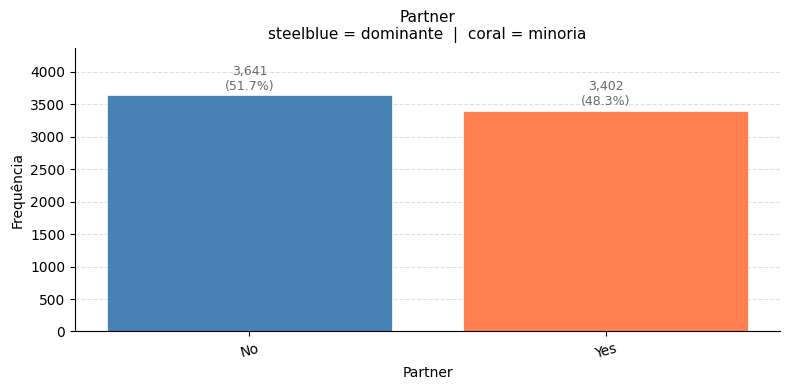

Partner | n=7043 | nulos=0 | categorias=2 | dominante='No' (51.7%) | minoria='Yes' (48.3%) | cats_raras=0 (<1%) | alta_concentracao=False
Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\projeto\reports\figures\univariate_cat_partner.png


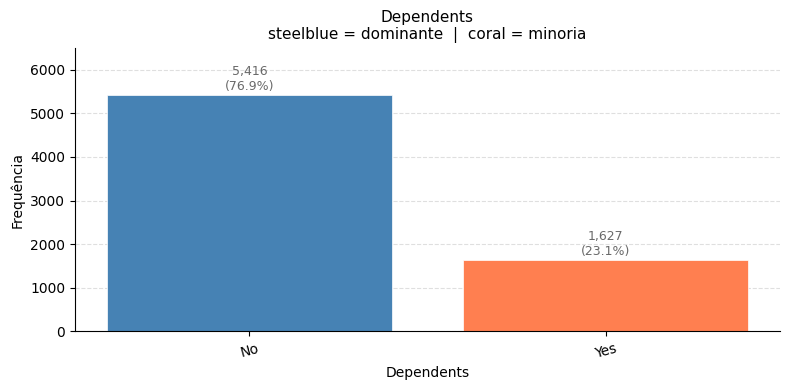

Dependents | n=7043 | nulos=0 | categorias=2 | dominante='No' (76.9%) | minoria='Yes' (23.1%) | cats_raras=0 (<1%) | alta_concentracao=False
Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\projeto\reports\figures\univariate_cat_dependents.png


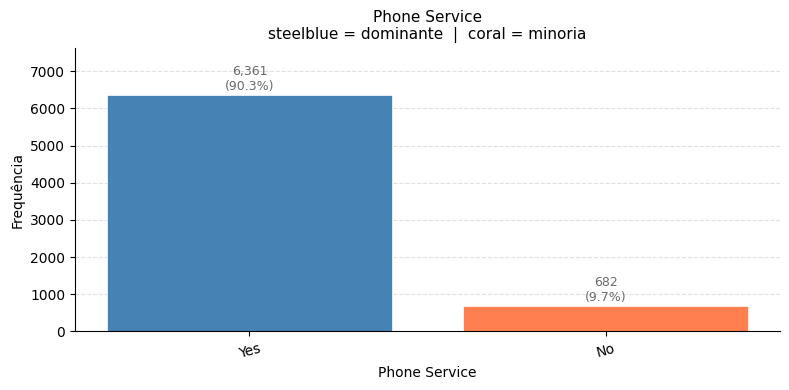

Phone Service | n=7043 | nulos=0 | categorias=2 | dominante='Yes' (90.3%) | minoria='No' (9.7%) | cats_raras=0 (<1%) | alta_concentracao=True
Phone Service | alta concentração: 'Yes' ocupa 90.3% — avaliar poder preditivo
Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\projeto\reports\figures\univariate_cat_phone_service.png


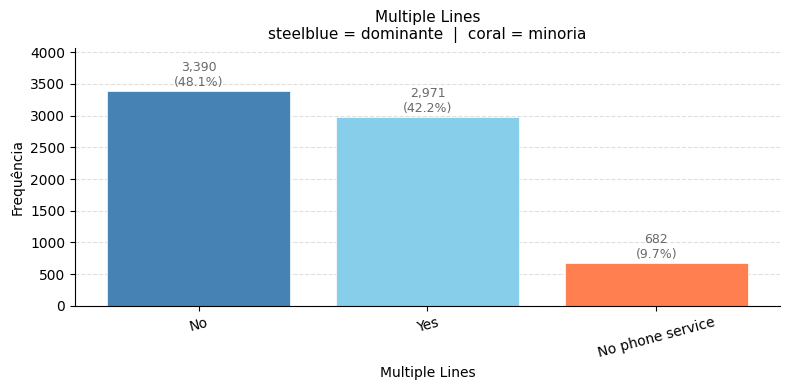

Multiple Lines | n=7043 | nulos=0 | categorias=3 | dominante='No' (48.1%) | minoria='No phone service' (9.7%) | cats_raras=0 (<1%) | alta_concentracao=False
Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\projeto\reports\figures\univariate_cat_multiple_lines.png


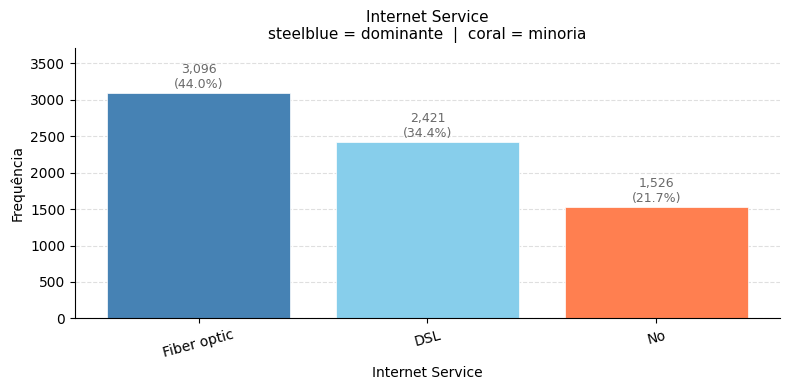

Internet Service | n=7043 | nulos=0 | categorias=3 | dominante='Fiber optic' (44.0%) | minoria='No' (21.7%) | cats_raras=0 (<1%) | alta_concentracao=False
Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\projeto\reports\figures\univariate_cat_internet_service.png


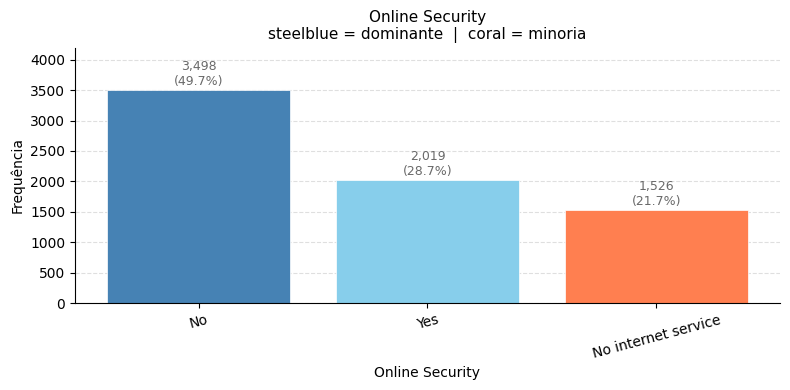

Online Security | n=7043 | nulos=0 | categorias=3 | dominante='No' (49.7%) | minoria='No internet service' (21.7%) | cats_raras=0 (<1%) | alta_concentracao=False
Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\projeto\reports\figures\univariate_cat_online_security.png


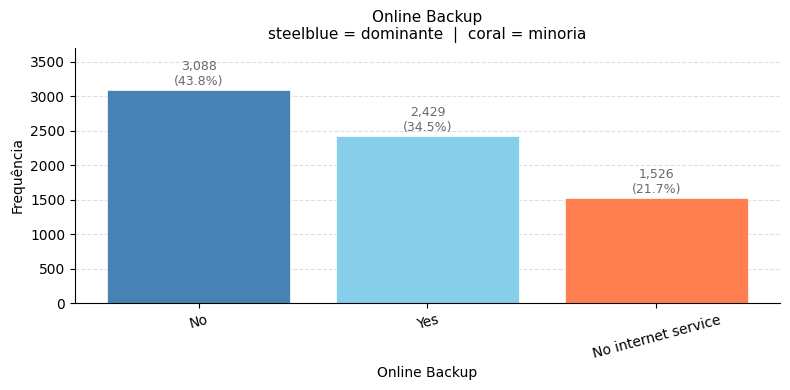

Online Backup | n=7043 | nulos=0 | categorias=3 | dominante='No' (43.8%) | minoria='No internet service' (21.7%) | cats_raras=0 (<1%) | alta_concentracao=False
Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\projeto\reports\figures\univariate_cat_online_backup.png


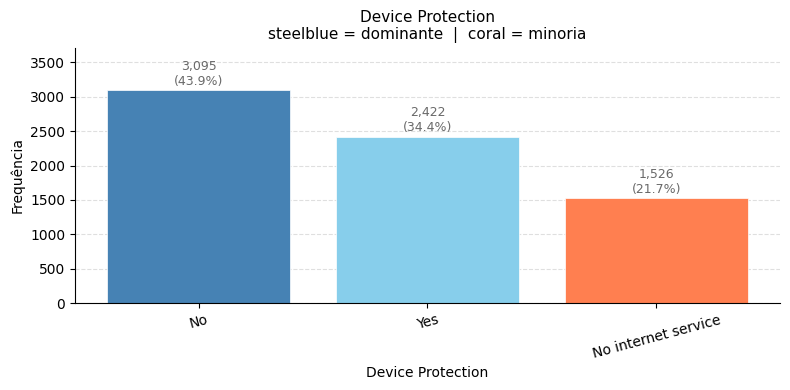

Device Protection | n=7043 | nulos=0 | categorias=3 | dominante='No' (43.9%) | minoria='No internet service' (21.7%) | cats_raras=0 (<1%) | alta_concentracao=False
Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\projeto\reports\figures\univariate_cat_device_protection.png


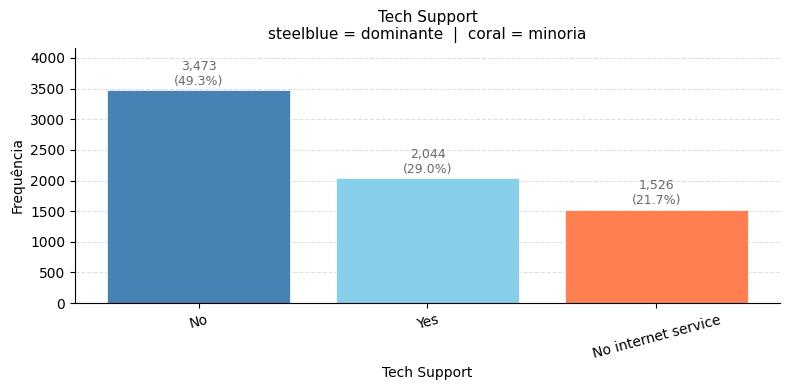

Tech Support | n=7043 | nulos=0 | categorias=3 | dominante='No' (49.3%) | minoria='No internet service' (21.7%) | cats_raras=0 (<1%) | alta_concentracao=False
Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\projeto\reports\figures\univariate_cat_tech_support.png


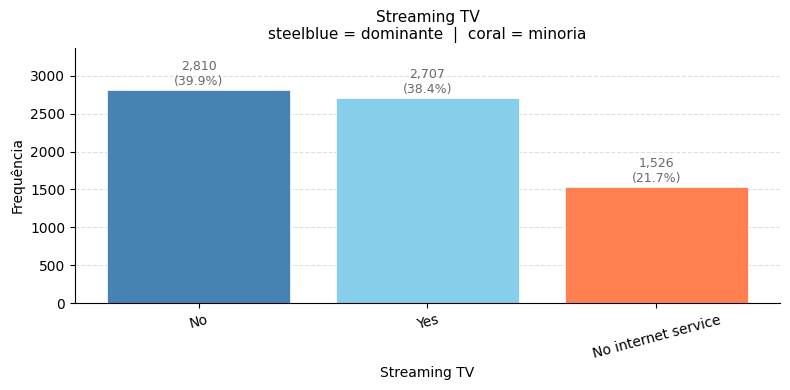

Streaming TV | n=7043 | nulos=0 | categorias=3 | dominante='No' (39.9%) | minoria='No internet service' (21.7%) | cats_raras=0 (<1%) | alta_concentracao=False
Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\projeto\reports\figures\univariate_cat_streaming_tv.png


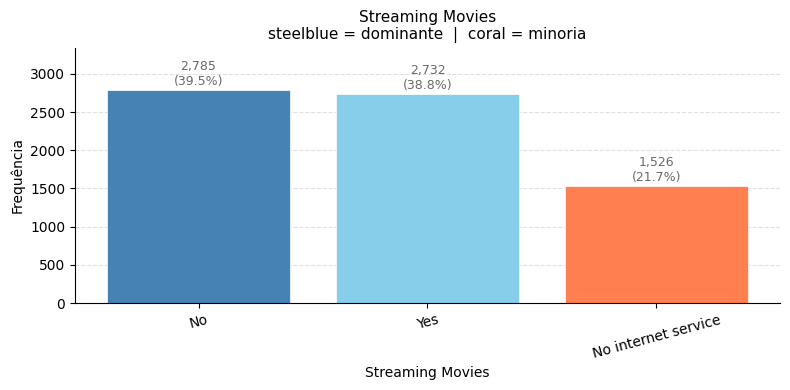

Streaming Movies | n=7043 | nulos=0 | categorias=3 | dominante='No' (39.5%) | minoria='No internet service' (21.7%) | cats_raras=0 (<1%) | alta_concentracao=False
Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\projeto\reports\figures\univariate_cat_streaming_movies.png


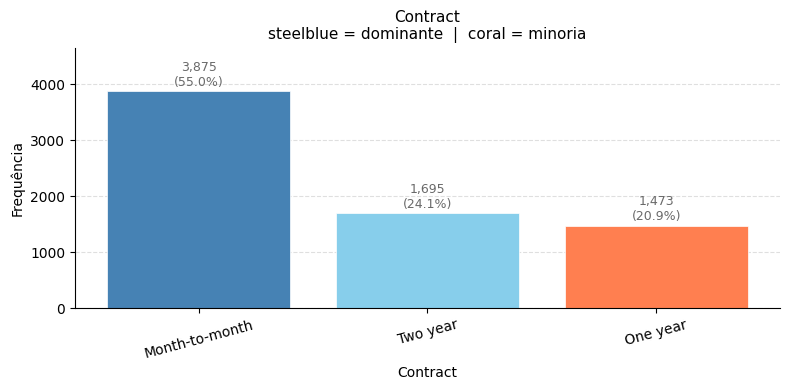

Contract | n=7043 | nulos=0 | categorias=3 | dominante='Month-to-month' (55.0%) | minoria='One year' (20.9%) | cats_raras=0 (<1%) | alta_concentracao=False
Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\projeto\reports\figures\univariate_cat_contract.png


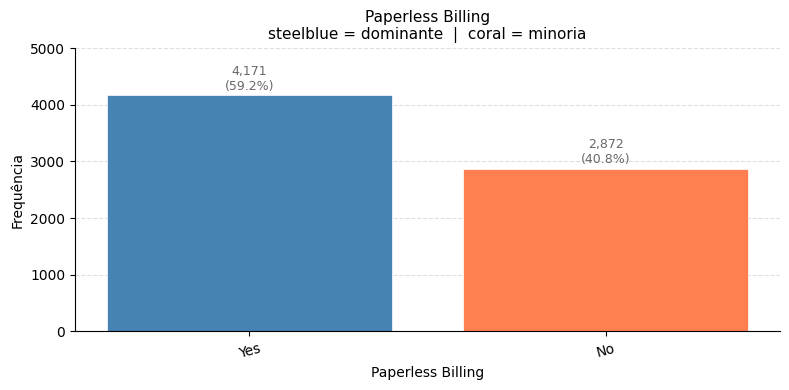

Paperless Billing | n=7043 | nulos=0 | categorias=2 | dominante='Yes' (59.2%) | minoria='No' (40.8%) | cats_raras=0 (<1%) | alta_concentracao=False
Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\projeto\reports\figures\univariate_cat_paperless_billing.png


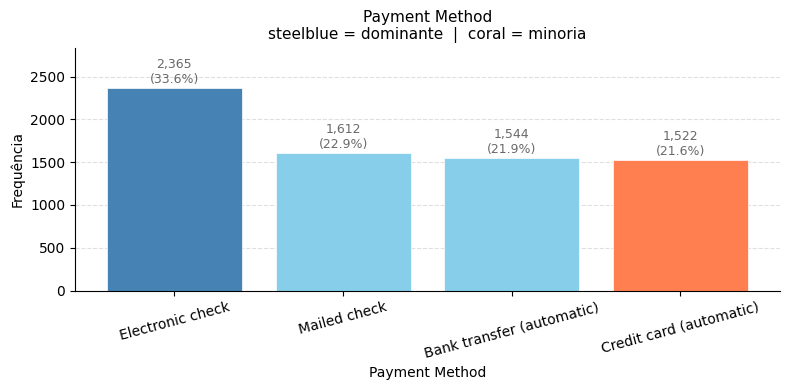

Payment Method | n=7043 | nulos=0 | categorias=4 | dominante='Electronic check' (33.6%) | minoria='Credit card (automatic)' (21.6%) | cats_raras=0 (<1%) | alta_concentracao=False
Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\projeto\reports\figures\univariate_cat_payment_method.png


In [67]:
# ── EDA Univariada — Variáveis Categóricas ────────────────────────────────────
for col in COLS_CAT:
    series    = df[col].dropna()
    freq_abs  = series.value_counts()
    freq_rel  = series.value_counts(normalize=True).mul(100).round(1)
    n_cats    = series.nunique()
    n_nulos   = df[col].isnull().sum()
    dominante = freq_abs.index[0]
    minoria   = freq_abs.index[-1]

    # Anomalia: categoria com menos de 1% — dado raro ou erro de digitação
    cats_raras = freq_rel[freq_rel < 1.0]
    # Concentração: dominante > 80% — variável pode ter baixo poder preditivo
    alta_concentracao = freq_rel.iloc[0] > 80.0

    fig, ax = plt.subplots(figsize=(8, 4))

    # ── Barras verticais ordenadas por frequência ─────────────────────────────
    cores_barras = [
        CORES["secundaria"] if cat == dominante
        else CORES["destaque"] if cat == minoria
        else CORES["primaria"]
        for cat in freq_abs.index
    ]
    bars = ax.bar(
        freq_abs.index,
        freq_abs.values,
        color=cores_barras,
        edgecolor="white",
        linewidth=0.5,
        zorder=2,
    )

    # Anotação no topo de cada barra: contagem + percentual
    for bar, count, pct in zip(bars, freq_abs.values, freq_rel.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + freq_abs.max() * 0.01,
            f"{count:,}\n({pct}%)",
            ha="center",
            va="bottom",
            fontsize=9,
            color=CORES["neutro"],
        )

    ax.set_title(
        f"{col}\nsteelblue = dominante  |  coral = minoria",
        fontsize=11,
    )
    ax.set_ylabel("Frequência")
    ax.set_xlabel(col)
    ax.set_ylim(0, freq_abs.max() * 1.2)  # espaço para anotações
    ax.yaxis.grid(True, linestyle="--", alpha=0.4, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="x", rotation=15)

    plt.tight_layout()
    output_path = REPORTS_FIGURES / f"univariate_cat_{col.lower().replace(' ', '_')}.png"
    plt.savefig(output_path, dpi=120, bbox_inches="tight")
    plt.show()
    plt.close()

    # ── Log estruturado por variável ──────────────────────────────────────────
    logger.info(
        "%s | n=%d | nulos=%d | categorias=%d | "
        "dominante='%s' (%.1f%%) | minoria='%s' (%.1f%%) | "
        "cats_raras=%d (<1%%) | alta_concentracao=%s",
        col,
        len(series),
        n_nulos,
        n_cats,
        dominante, freq_rel.loc[dominante],
        minoria,   freq_rel.loc[minoria],
        len(cats_raras),
        alta_concentracao,
    )

    # Alerta: categorias raras
    for cat, pct in cats_raras.items():
        logger.warning(
            "%s | categoria rara: '%s' = %.1f%% (%d registros)",
            col, cat, pct, freq_abs.loc[cat],
        )

    # Alerta: alta concentração
    if alta_concentracao:
        logger.warning(
            "%s | alta concentração: '%s' ocupa %.1f%% — avaliar poder preditivo",
            col, dominante, freq_rel.iloc[0],
        )

    logger.info("Artefato salvo: %s", output_path)

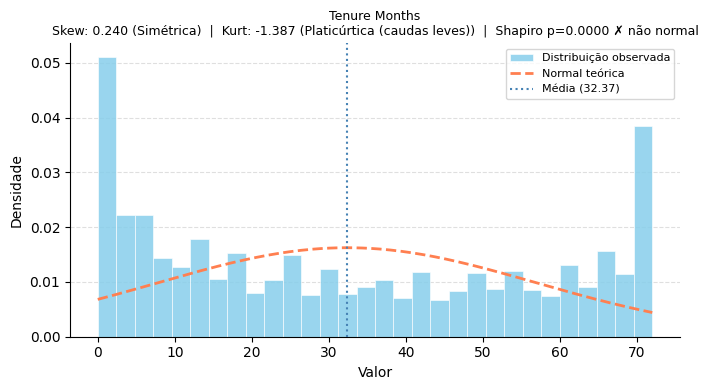

Tenure Months | skewness=0.240 (Simétrica) | kurtosis=-1.387 (Platicúrtica (caudas leves)) | shapiro_p=0.0000 | normal=False
Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\projeto\reports\figures\univariate_skew_kurt_tenure_months.png
Tenure Months | distribuição não normal (Shapiro p=0.0000) — considerar log1p ou Box-Cox na Etapa 1.03


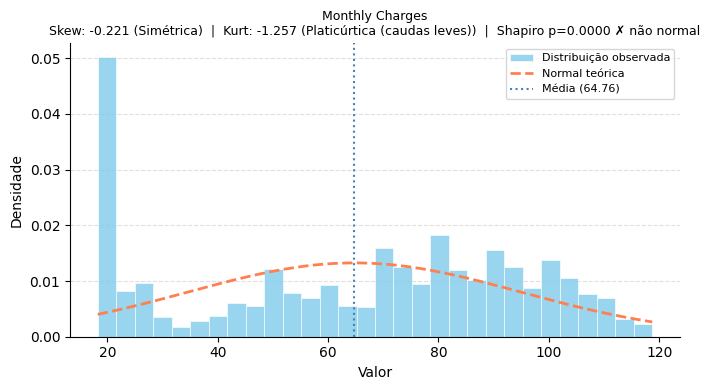

Monthly Charges | skewness=-0.221 (Simétrica) | kurtosis=-1.257 (Platicúrtica (caudas leves)) | shapiro_p=0.0000 | normal=False
Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\projeto\reports\figures\univariate_skew_kurt_monthly_charges.png
Monthly Charges | distribuição não normal (Shapiro p=0.0000) — considerar log1p ou Box-Cox na Etapa 1.03


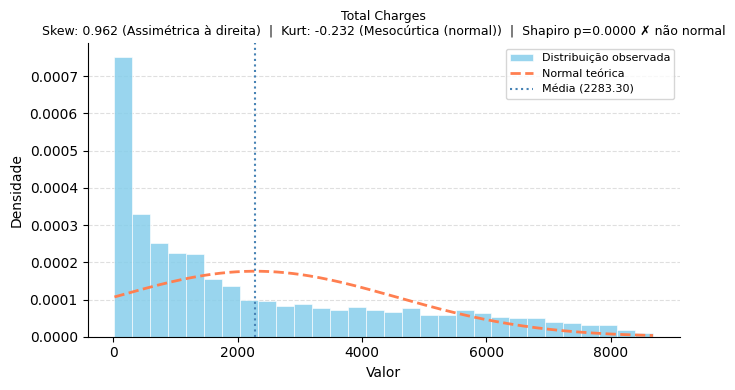

Total Charges | skewness=0.962 (Assimétrica à direita) | kurtosis=-0.232 (Mesocúrtica (normal)) | shapiro_p=0.0000 | normal=False
Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\projeto\reports\figures\univariate_skew_kurt_total_charges.png
Total Charges | distribuição não normal (Shapiro p=0.0000) — considerar log1p ou Box-Cox na Etapa 1.03


In [68]:
# ── Assimetria e Curtose — Variáveis Numéricas ────────────────────────────────
distribution_stats = []

for col in COLS_NUM:
    series   = df[col].dropna()
    skewness = series.skew()
    kurtosis = series.kurtosis()  # excess kurtosis (normal = 0)

    # Interpretação da assimetria
    if abs(skewness) < 0.5:
        interp_skew = "Simétrica"
    elif skewness > 0:
        interp_skew = "Assimétrica à direita"
    else:
        interp_skew = "Assimétrica à esquerda"

    # Interpretação da curtose (excess kurtosis)
    if abs(kurtosis) < 0.5:
        interp_kurt = "Mesocúrtica (normal)"
    elif kurtosis > 0:
        interp_kurt = "Leptocúrtica (caudas pesadas)"
    else:
        interp_kurt = "Platicúrtica (caudas leves)"

    # Teste de normalidade Shapiro-Wilk (amostra ≤ 5000)
    amostra = series.sample(min(len(series), 5000), random_state=RANDOM_STATE)
    _, p_valor = scipy_stats.shapiro(amostra)
    normal = p_valor > 0.05

    distribution_stats.append({
        "Coluna":       col,
        "Skewness":     round(skewness, 3),
        "Kurtosis":     round(kurtosis, 3),
        "Skew_interp":  interp_skew,
        "Kurt_interp":  interp_kurt,
        "Shapiro_p":    round(p_valor, 4),
        "Normal":       normal,
    })

    # ── Plot: histograma + curva normal teórica sobreposta ────────────────────
    fig, ax = plt.subplots(figsize=(7, 4))

    ax.hist(
        series,
        bins=30,
        color=CORES["primaria"],
        edgecolor="white",
        linewidth=0.5,
        density=True,   # normaliza para sobrepor curva teórica
        alpha=0.85,
        zorder=2,
        label="Distribuição observada",
    )

    # Curva normal teórica — referência visual para avaliar desvio da normalidade
    x = np.linspace(series.min(), series.max(), 200)
    curva_normal = scipy_stats.norm.pdf(x, series.mean(), series.std())
    ax.plot(
        x,
        curva_normal,
        color=CORES["destaque"],
        linewidth=2,
        linestyle="--",
        label="Normal teórica",
        zorder=3,
    )

    # Linha vertical na média
    ax.axvline(
        series.mean(),
        color=CORES["secundaria"],
        linewidth=1.5,
        linestyle=":",
        label=f"Média ({series.mean():.2f})",
        zorder=3,
    )

    ax.set_title(
        f"{col}\n"
        f"Skew: {skewness:.3f} ({interp_skew})  |  "
        f"Kurt: {kurtosis:.3f} ({interp_kurt})  |  "
        f"Shapiro p={p_valor:.4f} {'✓ normal' if normal else '✗ não normal'}",
        fontsize=9,
    )
    ax.set_xlabel("Valor")
    ax.set_ylabel("Densidade")
    ax.yaxis.grid(True, linestyle="--", alpha=0.4, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(fontsize=8)

    plt.tight_layout()
    output_path = REPORTS_FIGURES / f"univariate_skew_kurt_{col.lower().replace(' ', '_')}.png"
    plt.savefig(output_path, dpi=120, bbox_inches="tight")
    plt.show()
    plt.close()

    # ── Log estruturado por variável ──────────────────────────────────────────
    logger.info(
        "%s | skewness=%.3f (%s) | kurtosis=%.3f (%s) | shapiro_p=%.4f | normal=%s",
        col,
        skewness, interp_skew,
        kurtosis, interp_kurt,
        p_valor,
        normal,
    )
    logger.info("Artefato salvo: %s", output_path)

    # Alerta: não normalidade — relevante para escolha de transformações
    if not normal:
        logger.warning(
            "%s | distribuição não normal (Shapiro p=%.4f) — considerar log1p ou Box-Cox na Etapa 1.03",
            col, p_valor,
        )